In [1]:
import trackpy as tp
import pims
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.optimize import curve_fit

# Funciones

In [2]:
def frame_x_frame(frame, diametro, percentil, luz):
    # Cambiá el número por el fotograma que querés investigar
    frame_idx = frame

    frame_orig = video_original[frame_idx]
    frame_proc = video_limpio[frame_idx]

    # Ajustá el diámetro y minmass según lo que vengas usando
    f_test = tp.locate(frame_proc, diametro, minmass=luz, percentile=percentil)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    estilo_circulos = {'mew': 0.8, 'alpha': 0.6} # mew = grosor, alpha = transparencia

    # Panel 1: Original
    tp.annotate(f_test, frame_orig, ax=ax1, 
                imshow_style={'cmap': 'gray'}, 
                plot_style=estilo_circulos)
    ax1.set_title(f'Original - Frame {frame_idx}')

    # Panel 2: Limpio
    tp.annotate(f_test, frame_proc, ax=ax2, 
                plot_style=estilo_circulos)
    ax2.set_title(f'Limpio + Detecciones ({len(f_test)} partículas)')

    plt.show()

In [17]:
def anal_video(video, frames, diametro, percentil, luz, dist_max, memoria):
    limite_frames = frames
    f = tp.batch(video_limpio[:limite_frames], diametro, minmass=luz, percentile=percentil, processes=1)  #(video, tamaño de las partículas en pixeles, sensibilidad del detector menos es más sensible y a la mínima piensa que hay una part, procesos siemrpe va 1)

    # 2. Enlazás usando 't'. (Subí el rango de búsqueda a 15 para evitar que se corten)
    t = tp.link(f, dist_max, memory=memoria)  # (df, si entre frame y frame una part se desplaza menos de esos pixeles se considera la misma partícula, frames que aguanta si una part deja de ser detectada que si vuelve a ser detectada la reconoce como la misma)

    cap = cv2.VideoCapture(video)
    
    # 1. Leer propiedades del video original
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # 2. Configurar el formato de salida (codec XVID)
    nombre = input("Ingresa el nombre para guardar el video (sin extensión): ")
    if no nombre.strip():
        nombre = "Tracking_Guardado" # Nombre por defecto si presionas Enter sin escribir nada

    nombre_archivo = f"{nombre}.avi"

    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(nombre_archivo, fourcc, fps, (width, height))

    frame_idx = 0

    while cap.isOpened() and frame_idx < limite_frames:
        ret, frame = cap.read()
        if not ret:
            break
            
        actuales = t[t['frame'] == frame_idx]
        
        for _, p in actuales.iterrows():
            x, y = int(p['x']), int(p['y'])
            cv2.circle(frame, (x, y), 12, (0, 0, 255), 2)
            cv2.putText(frame, str(int(p['particle'])), (x+15, y-15), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (19, 69, 139), 1)

        # 3. Guardar el frame modificado en el archivo
        out.write(frame)
        
        # Podés mantener imshow para ver el progreso mientras guarda
        cv2.imshow('Guardando video...', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
        frame_idx += 1

    # 4. Cerrar recursos (si olvidás out.release(), el video no va a abrir)
    cap.release()
    out.release() 
    cv2.destroyAllWindows()

SyntaxError: invalid syntax (2475258377.py, line 17)

# Pruebas

In [3]:
video = pims.Video('Libre.avi')
# 1. Cargar el video de fondo
video_fondo = pims.Video('FONDO_LIBRE.avi') 

# Opcional: podés comprobar cuántos fotogramas tiene antes de procesar
print(f"Total de fotogramas: {len(video)}")

Total de fotogramas: 4062


In [4]:
# 2. Extraer una muestra (ej. 100 fotogramas) para no saturar la RAM
n_frames = min(100, len(video_fondo))
muestra_fondo = [video_fondo[i][:, :, 0].astype(float) for i in range(n_frames)]

# 3. Calcular la mediana para obtener un único fondo estático limpio
fondo_estatico = np.median(muestra_fondo, axis=0)

from scipy.ndimage import gaussian_filter

# Asume que ya calculaste la variable 'fondo_estatico' en una celda anterior

@pims.pipeline
def restar_y_suavizar(frame):
    frame_gris = frame[:, :, 0].astype(float)
    resta = fondo_estatico - frame_gris
    resta_recortada = np.clip(resta, 0, 255)
    return gaussian_filter(resta_recortada, sigma=2) # Probá cambiar el 2 si hace falta

video_original = pims.Video('Libre.avi')
video_limpio = restar_y_suavizar(video_original)

Frame a Frame

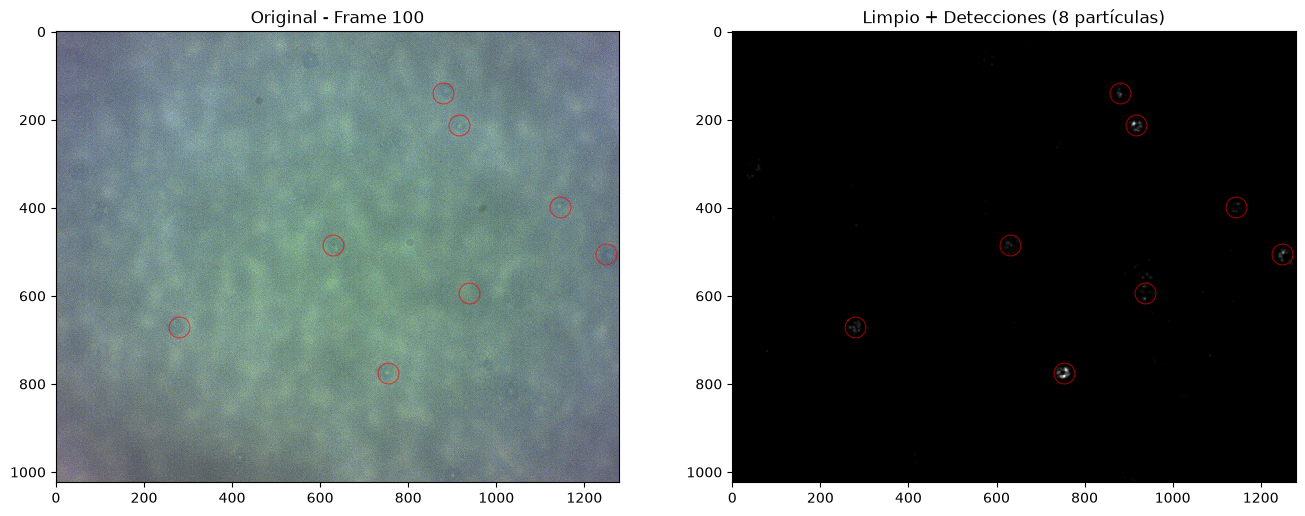

In [ ]:
frame_x_frame(100, 45, 90, 5) #(Frame, diametro, percentile, minmass)

Video

In [21]:
anal_video('Libre.avi', 200, 45, 90, 9, 25, 40) #(video, frames, diamtero, percentil, minmass, dist_max, memoria)

Frame 199: 8 trajectories present.


Calibración pixeles metros

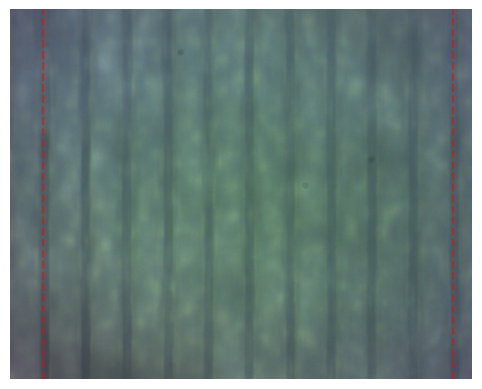

mpp: 0.0947867298578199


In [20]:
imagen = plt.imread('calibración.png')

plt.imshow(imagen)
plt.axvline(x=85, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=1140, color='red', linestyle='--', alpha=0.5)
plt.axis('off') # Opcional: oculta los ejes numéricos
plt.show()

mpp=100/(1140-85)
print(f'mpp: {mpp}')

Cuentas

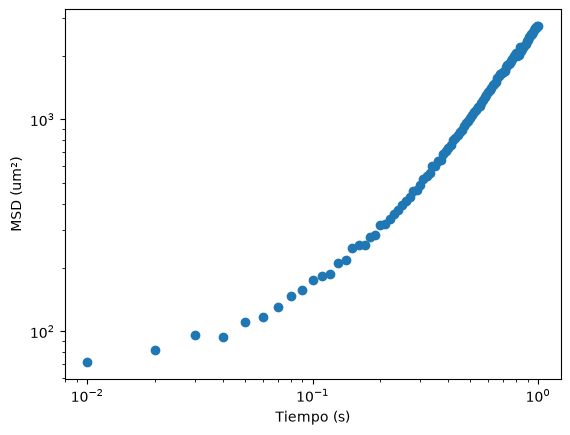

In [ ]:
# 1. Calcular y restar la deriva global del fluido
deriva = tp.compute_drift(t)
t_sin_deriva = tp.subtract_drift(t, deriva)

# 2. Calcular el MSD promedio de todas las partículas (Ensemble MSD)
# max_lagtime limita hasta qué intervalo temporal calcularlo
msd = tp.emsd(t_sin_deriva, mpp=mpp, fps=100.0, max_lagtime=100) #mpp: micrones por pixel

# 3. Graficar en escala log-log (estándar para analizar difusión)
import matplotlib.pyplot as plt

plt.plot(msd.index, msd, 'o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tiempo (s)')
plt.ylabel('MSD (um²)')
plt.show()

# Análisis del video de otro grupo

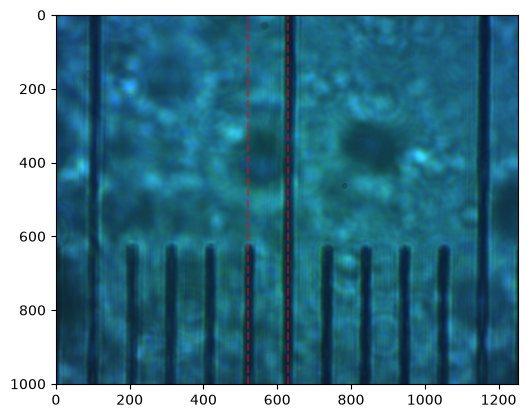

mpp= 0.09090909090909091


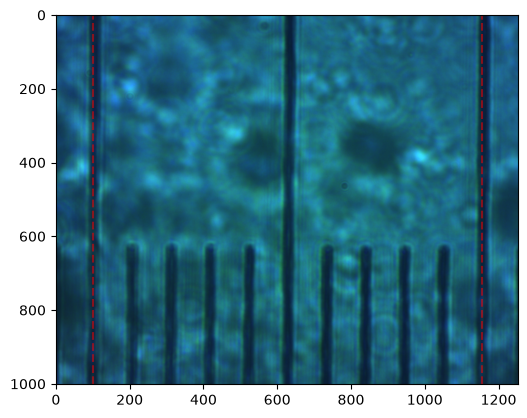

0.0947867298578199


In [2]:
imagen = plt.imread('calibracion_otros.png')

plt.imshow(imagen)
plt.axvline(x=520, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=630, color='red', linestyle='--', alpha=0.5)
#plt.axis('off') # Opcional: oculta los ejes numéricos
plt.show()

print(f'mpp= {1/((630-520)/10)}')

x1=100
x2=1155

plt.imshow(imagen)
plt.axvline(x=x1, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=x2, color='red', linestyle='--', alpha=0.5)
#plt.axis('off') # Opcional: oculta los ejes numéricos
plt.show()
print(100/(x2-x1))

para mejorar el método de calibración pixeles-milímetros, es recomendable usar las lineas extemas para minimizar el error relativo

In [3]:
video_original = pims.Video('mov_libre_otros.avi')

# Opcional: podés comprobar cuántos fotogramas tiene antes de procesar
print(f"Total de fotogramas: {len(video_original)}")

Total de fotogramas: 1592


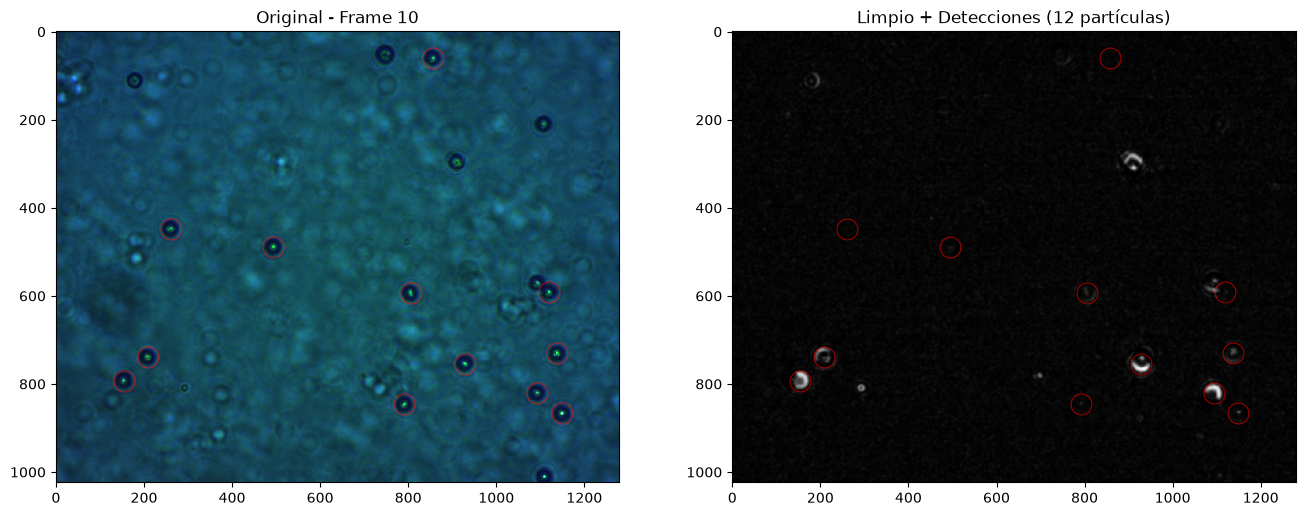

In [32]:
# Cambiá el número por el fotograma que querés investigar
frame_idx = 10

frame_orig = video_original[frame_idx]
frame_gris = cv2.cvtColor(frame_orig, cv2.COLOR_RGB2GRAY)

# 2. Aplicar el filtro espacial
# lshort: tamaño del ruido (típicamente 1 o 3)
# llong: tamaño del fondo a suprimir (mayor al de la partícula, ej. 51 o 101)
frame_filtrado = tp.bandpass(frame_gris, lshort=3, llong=101)

# Ajustá el diámetro y minmass según lo que vengas usando
f_test = tp.locate(frame_filtrado, 11, minmass=300, percentile=99.9, separation=35, invert=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

estilo_circulos = {'mew': 0.8, 'alpha': 0.6} # mew = grosor, alpha = transparencia

# Panel 1: Original
tp.annotate(f_test, frame_orig, ax=ax1, 
            imshow_style={'cmap': 'gray'}, 
            plot_style=estilo_circulos)
ax1.set_title(f'Original - Frame {frame_idx}')

# Panel 2: Limpio
tp.annotate(f_test, frame_proc, ax=ax2, 
            plot_style=estilo_circulos)
ax2.set_title(f'Limpio + Detecciones ({len(f_test)} partículas)')

plt.show()

In [ ]:
@pims.pipeline
def preprocesar_frame(frame):
    # Asegurate de usar COLOR_RGB2GRAY o COLOR_BGR2GRAY según cómo cargaste el video
    frame_gris = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    return tp.bandpass(frame_gris, lshort=3, llong=101)

video_original = pims.Video('mov_libre_otros.avi')
# Se aplica el decorador al objeto de video original
video_filtrado = preprocesar_frame(video_original)

limite_frames = 1592
f = tp.batch(video_filtrado[:limite_frames], 11, minmass=300, percentile=99.9, separation=35, invert=False, processes=1)  #(video, tamaño de las partículas en pixeles, sensibilidad del detector menos es más sensible y a la mínima piensa que hay una part, procesos siemrpe va 1)

# 2. Enlazás usando 't'. (Subí el rango de búsqueda a 15 para evitar que se corten)
t = tp.link(f, 25, memory=50)  # (df, si entre frame y frame una part se desplaza menos de esos pixeles se considera la misma partícula, frames que aguanta si una part deja de ser detectada que si vuelve a ser detectada la reconoce como la misma)

cap = cv2.VideoCapture('mov_libre_otros.avi')
 
# 1. Leer propiedades del video original
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# 2. Configurar el formato de salida (codec XVID)
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('Tracking_otros.avi', fourcc, fps, (width, height))

frame_idx = 0

while cap.isOpened() and frame_idx < limite_frames:
    ret, frame = cap.read()
    if not ret:
        break
        
    actuales = t[t['frame'] == frame_idx]
    
    for _, p in actuales.iterrows():
        x, y = int(p['x']), int(p['y'])
        cv2.circle(frame, (x, y), 12, (0, 0, 255), 2)
        cv2.putText(frame, str(int(p['particle'])), (x+15, y-15), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (19, 69, 139), 1)

    # 3. Guardar el frame modificado en el archivo
    out.write(frame)
    
    # Podés mantener imshow para ver el progreso mientras guarda
    cv2.imshow('Guardando video...', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
        
    frame_idx += 1

# 4. Cerrar recursos (si olvidás out.release(), el video no va a abrir)
cap.release()
out.release() 
cv2.destroyAllWindows()

Frame 1591: 13 trajectories present.


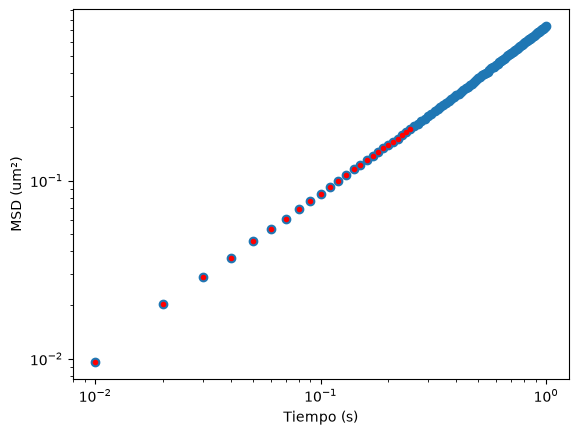

In [46]:
# 1. Calcular y restar la deriva global del fluido
deriva = tp.compute_drift(t)
t_sin_deriva = tp.subtract_drift(t, deriva)

# 2. Calcular el MSD promedio de todas las partículas (Ensemble MSD)
# max_lagtime limita hasta qué intervalo temporal calcularlo
msd = tp.emsd(t_sin_deriva, mpp=0.0947867298578199, fps=100.0, max_lagtime=100) #mpp: milimetros por pixel

# 3. Graficar en escala log-log (estándar para analizar difusión)
limite = int(len(msd.index) * 0.25)
t_fit = msd.index[:limite]
msd_fit = msd[:limite]

plt.plot(msd.index, msd, 'o')
plt.plot(t_fit,msd_fit, '.r')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tiempo (s)')
plt.ylabel('MSD (um²)')
plt.show()

In [ ]:
# Truncar los datos al primer 25% para evitar el ruido estadístico de la cola
limite = int(len(tiempo) * 0.25)
t_fit = tiempo[:limite]
msd_fit = msd[:limite]

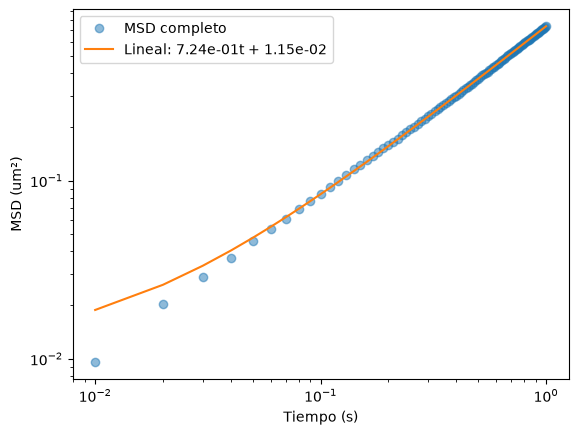

In [48]:
# Ajuste lineal con polyfit (grado 1)
coef_lin = np.polyfit(msd.index, msd, 1)
ajuste_lin = np.polyval(coef_lin, msd.index)

plt.plot(msd.index, msd, 'o', label='MSD completo', alpha=0.5)
plt.plot(msd.index, ajuste_lin, '-', label=f'Lineal: {coef_lin[0]:.2e}t + {coef_lin[1]:.2e}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tiempo (s)')
plt.ylabel('MSD (um²)')
plt.legend()
plt.show()

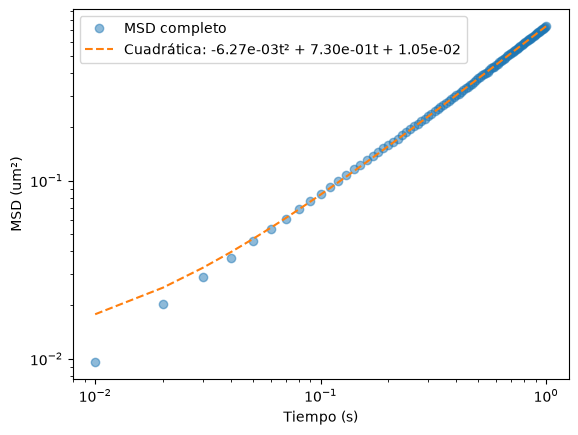

In [49]:
# Definir la función para curve_fit
def cuadratica(x, a, b, c):
    return a * x**2 + b * x + c

# Ajuste cuadrático con curve_fit
coef_cuad, covarianza = curve_fit(cuadratica, msd.index, msd)
ajuste_cuad = cuadratica(msd.index, *coef_cuad)

# Graficar
plt.plot(msd.index, msd, 'o', label='MSD completo', alpha=0.5)
plt.plot(msd.index, ajuste_cuad, '--', label=f'Cuadrática: {coef_cuad[0]:.2e}t² + {coef_cuad[1]:.2e}t + {coef_cuad[2]:.2e}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tiempo (s)')
plt.ylabel('MSD (um²)')
plt.legend()
plt.show()